<html><div style="font-size:7pt">This notebook may contain text, code and images generated by artificial intelligence. Used model: coder, vision model: None, endpoint: https://llm.ai.e-infra.cz/v1/, bia-bob version: 0.34.3.. It is good scientific practice to check the code and results it produces carefully. <a href="https://github.com/haesleinhuepf/bia-bob">Read more about code generation using bia-bob</a></div></html>

# Penguin Data Exploration

## Introduction
This notebook performs an exploratory data analysis (EDA) on the raw penguin dataset located at `../data/penguins_raw.csv`. The goal is to understand the data structure, quality, and distribution without making assumptions about column names or specific values. This process is essential for creating accurate Data Management Plans (DMPs), ensuring data quality before analysis, and identifying potential issues such as missing values or outliers that require cleaning.

## Planned Steps
1. **Import Libraries**: Load necessary Python libraries for data manipulation, statistical analysis, and visualization.
2. **Load Data**: Read the CSV file dynamically to inspect the actual column names and data types.
3. **Initial Data Profiling**: Display the first few rows and basic information about the dataset structure.
4. **Missing Value Analysis**: Calculate and visualize the extent of missing data across all columns.
5. **Statistical Summary**: Generate descriptive statistics for numerical and categorical variables.
6. **Outlier Detection**: Identify potential outliers using statistical methods (IQR) for numerical columns.
7. **Distribution Visualization**: Create histograms and boxplots to visualize the distribution of key features.
8. **Summary for DMP**: Compile findings into a structured summary suitable for inclusion in a Data Management Plan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Step 1: Load the Data
We load the dataset from the specified relative path. We do not assume the filename or extension beyond what is provided, but we handle the path robustly. This step reveals the actual column names present in the source file.

In [2]:
file_path = Path("../data/penguins_raw.csv")

# Check if file exists before loading
if not file_path.exists():
    raise FileNotFoundError(f"File not found at: {file_path}")

# Load the CSV file
df = pd.read_csv(file_path)

# Display the first 5 rows to see actual column names and data preview
display(df.head())

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


### Step 2: Initial Data Profiling
Understanding the schema is critical. We check the data types, the number of rows/columns, and memory usage. This helps determine how the data should be stored and processed in the future.

In [3]:
# Get detailed info about the dataframe
print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types and Non-Null Counts:")
display(df.info())

Dataset Shape: (344, 17)

Column Names:
['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage', 'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments']

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length

None

### Step 3: Missing Value Analysis
Missing data can bias results and affect storage requirements. We calculate the count and percentage of missing values for every column to identify which fields require imputation or exclusion strategies.

Columns with missing values:


,Missing_Count,Missing_Percent
Comments,290,84.302326
Delta 15 N (o/oo),14,4.069767
Delta 13 C (o/oo),13,3.779070
Sex,11,3.197674
Culmen Length (mm),2,0.581395
Body Mass (g),2,0.581395
Flipper Length (mm),2,0.581395
Culmen Depth (mm),2,0.581395


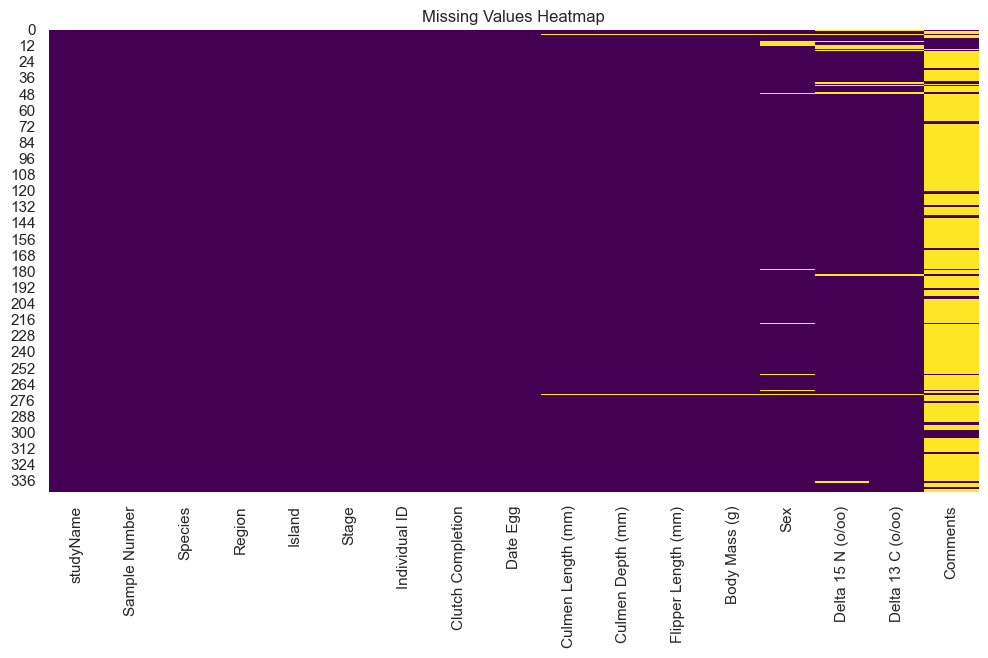

In [4]:
# Calculate missing values per column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent
}).sort_values(by='Missing_Count', ascending=False)

# Filter to show only columns with missing values
missing_filtered = missing_summary[missing_summary['Missing_Count'] > 0]

if not missing_filtered.empty:
    print("Columns with missing values:")
    display(missing_filtered)
else:
    print("No missing values detected in the dataset.")

# Visualize missingness matrix
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### Step 4: Statistical Summary
We generate descriptive statistics. For numerical columns, this includes mean, std, min, max, and quartiles. For categorical columns, we look at value counts. This provides a baseline for expected ranges and identifies potential data entry errors.

In [12]:
# Numerical statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical Statistics:")
display(df[numeric_cols].describe())

# Categorical statistics
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
print("\nCategorical Unique Values:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Numerical Statistics:


,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670



Categorical Unique Values:

studyName:
studyName
PAL0910    120
PAL0809    114
PAL0708    110
Name: count, dtype: int64

Species:
Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64

Region:
Region
Anvers    344
Name: count, dtype: int64

Island:
Island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Stage:
Stage
Adult, 1 Egg Stage    344
Name: count, dtype: int64

Individual ID:
Individual ID
N6A1      3
N6A2      3
N8A1      3
N8A2      3
N13A1     3
         ..
N98A2     1
N99A1     1
N99A2     1
N100A1    1
N100A2    1
Name: count, Length: 190, dtype: int64

Clutch Completion:
Clutch Completion
Yes    308
No      36
Name: count, dtype: int64

Date Egg:
Date Egg
2007-11-27    18
2007-11-16    16
2008-11-09    16
2009-11-18    14
2008-11-06    12
2008-11-13    12
2009-11-21    12
2008-11-04    12
2008-11-14    10
2009-11-15   

### Step 5: Outlier Detection
Using the Interquartile Range (IQR) method, we detect outliers in numerical columns. Outliers may represent measurement errors or rare biological phenomena. Identifying them is crucial for deciding whether to keep, transform, or remove them during data cleaning.

No significant outliers detected using the IQR method.


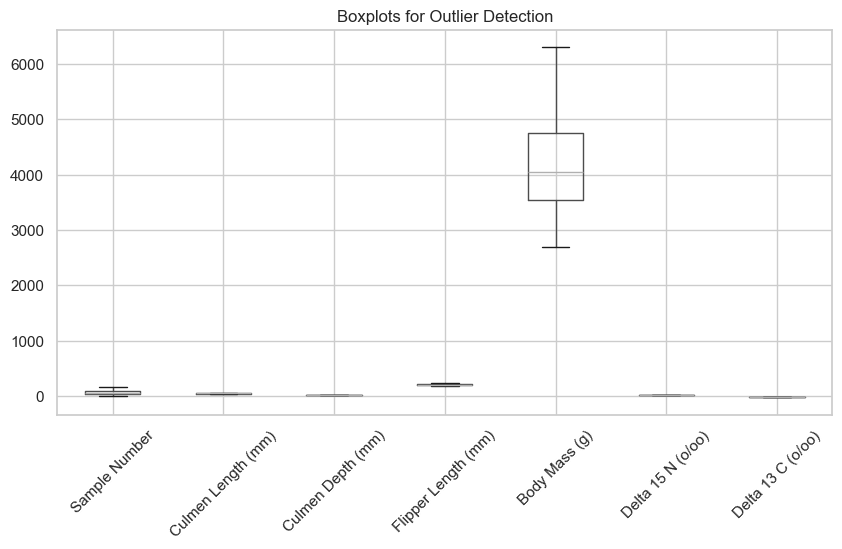

In [7]:
outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    
    if outlier_count > 0:
        outlier_report[col] = {
            'Count': outlier_count,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        }

if outlier_report:
    print("Detected Outliers by Column:")
    for col, stats in outlier_report.items():
        print(f"Column '{col}': {stats['Count']} outliers (Bounds: {stats['Lower_Bound']:.2f} - {stats['Upper_Bound']:.2f})")
else:
    print("No significant outliers detected using the IQR method.")

# Boxplot visualization for numerical columns
if len(numeric_cols) > 0:
    plt.figure(figsize=(10, 5))
    df[numeric_cols].boxplot()
    plt.title('Boxplots for Outlier Detection')
    plt.xticks(rotation=45)
    plt.show()

### Step 6: Distribution Visualization
Visualizing distributions helps in understanding the underlying data shape (e.g., normal, skewed, bimodal). This informs decisions on normalization or transformation techniques required for downstream modeling.

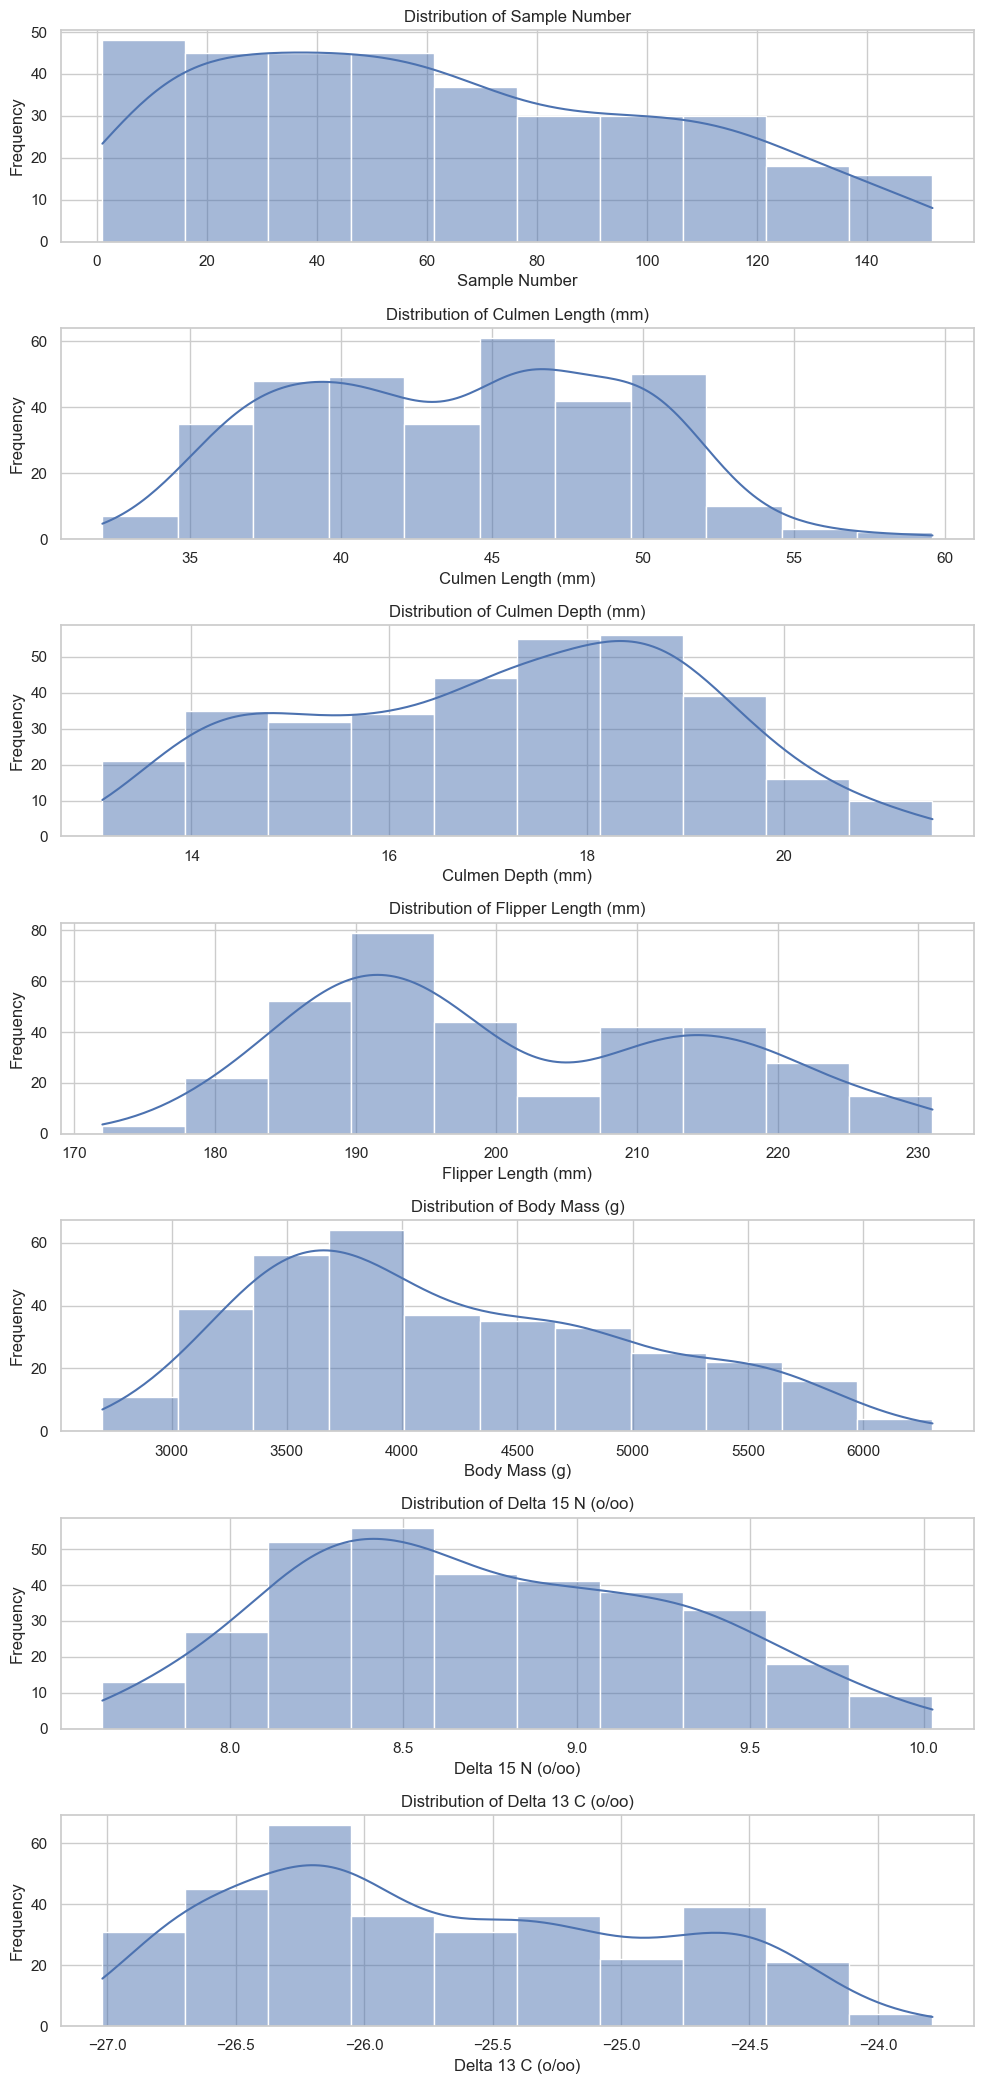

In [8]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)))

# Handle case where there is only one plot vs multiple
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Step 7: Summary for Data Management Plan (DMP)
The following section summarizes the exploration findings. This text is structured to be directly copied into the "Data Quality" and "Data Description" sections of a Data Management Plan.

In [11]:
print("="*60)
print("DATA EXPLORATION SUMMARY FOR DMP")
print("="*60)

dmp_summary = f"""
1. DATASET OVERVIEW
   - Source File: {file_path.name}
   - Total Records: {len(df)}
   - Total Variables: {len(df.columns)}
   - Variable Types: {len(numeric_cols)} numerical, {len(categorical_cols)} categorical

2. DATA QUALITY ASSESSMENT
   - Missing Values: 
     {missing_summary.to_string() if not missing_summary.empty else 'None detected.'}\n
   - Outliers:
     {f'Detected in columns: {list(outlier_report.keys())}' if outlier_report else 'No significant outliers detected.'}

3. DISTRIBUTION CHARACTERISTICS
   - Numerical variables show the following characteristics: 
     (See generated histograms for skewness and modality details).
   - Categorical variables have distinct categories suitable for grouping.

4. RECOMMENDATIONS FOR DATA MANAGEMENT
   - Retention: Raw data will be preserved as-is in the repository.
   - Cleaning: A derived clean version will be created addressing missing values and outliers identified above.
   - Documentation: Codebooks will be generated based on the unique values observed in categorical columns.
   - FAIR Compliance: Metadata will capture the exact column names and data types identified in this exploration.
"""

print(dmp_summary)

DATA EXPLORATION SUMMARY FOR DMP

1. DATASET OVERVIEW
   - Source File: penguins_raw.csv
   - Total Records: 344
   - Total Variables: 17
   - Variable Types: 7 numerical, 10 categorical

2. DATA QUALITY ASSESSMENT
   - Missing Values: 
                          Missing_Count  Missing_Percent
Comments                       290        84.302326
Delta 15 N (o/oo)               14         4.069767
Delta 13 C (o/oo)               13         3.779070
Sex                             11         3.197674
Culmen Length (mm)               2         0.581395
Body Mass (g)                    2         0.581395
Flipper Length (mm)              2         0.581395
Culmen Depth (mm)                2         0.581395
studyName                        0         0.000000
Sample Number                    0         0.000000
Clutch Completion                0         0.000000
Individual ID                    0         0.000000
Stage                            0         0.000000
Island                        